# Notebook 13: A/B Testing Framework for DCN-v2 Deployment

## Purpose

This notebook implements a **production-grade A/B testing framework** for evaluating DCN-v2 against XGBoost in a simulated online environment. While offline evaluation (Notebooks 05, 08, 11) measures ranking quality on held-out data, A/B testing addresses the real deployment question: **does switching rankers improve user outcomes at scale?**

## Why A/B testing differs from offline evaluation

| Aspect | Offline Evaluation | A/B Testing |
|--------|-------------------|-------------|
| Data | Historical test set | Live user traffic (simulated) |
| Confounders | Controlled (paired) | Feedback loops, novelty effects |
| Sample size | Fixed | Grows over time (sequential) |
| Decision | Which is better? | When to stop and ship? |
| Risks | None (retrospective) | Degraded user experience |

## Framework Components

1. **Power Analysis**: Sample size determination for desired sensitivity
2. **Sequential Testing**: Group Sequential Design with O'Brien-Fleming alpha-spending to control type-I error while enabling early stopping
3. **Guardrail Metrics**: Safety checks that trigger automatic rollback
4. **Variance Reduction**: CUPED (Controlled-experiment Using Pre-Experiment Data) for tighter confidence intervals
5. **Novelty Detection**: Identifying and adjusting for novelty/primacy effects

## Key Design Decisions

- **Primary metric**: NDCG@10 (measures ranking quality directly)
- **Guardrails**: Latency P95, error rate, user session length
- **MDE (Minimum Detectable Effect)**: 2% relative improvement in NDCG@10
- **Alpha**: 0.05 (two-sided), with alpha-spending for interim analyses
- **Power**: 0.80
- **Max duration**: 14 days (2 interim looks at days 5 and 10)

## Section 1: Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass, field
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print("A/B Testing Framework for DCN-v2 Deployment")
print("=" * 50)

A/B Testing Framework for DCN-v2 Deployment


## Section 2: Power Analysis

Before running an experiment, we must determine how many users we need to detect a meaningful improvement. The minimum detectable effect (MDE) is the smallest improvement worth deploying for -- below this threshold, the engineering cost of switching models outweighs the benefit.

For recommendation ranking, a 2% relative improvement in NDCG@10 is our MDE, informed by:
- Industry benchmarks where 1-3% NDCG lifts are considered significant
- The cost of model serving infrastructure changes
- Expected engagement impact from ranking improvements

In [2]:
@dataclass
class PowerAnalysisConfig:
    alpha: float = 0.05
    power: float = 0.80
    mde_relative: float = 0.02  # 2% relative improvement
    baseline_mean: float = 0.15  # Baseline NDCG@10 from offline eval
    baseline_std: float = 0.12  # Std of NDCG@10 across users
    n_interim_looks: int = 2  # O'Brien-Fleming spending
    daily_users: int = 10000  # Simulated daily traffic


def compute_sample_size(config: PowerAnalysisConfig) -> Dict:
    """Compute required sample size per group for two-sample t-test.

    Accounts for:
    - Two-sided test
    - Multiple interim analyses (inflation factor)
    - Unequal variance (Welch approximation)
    """
    # Absolute MDE
    mde_absolute = config.baseline_mean * config.mde_relative

    # Standard formula: n = 2 * (z_alpha/2 + z_beta)^2 * sigma^2 / delta^2
    z_alpha = stats.norm.ppf(1 - config.alpha / 2)
    z_beta = stats.norm.ppf(config.power)

    n_per_group_base = 2 * ((z_alpha + z_beta) ** 2) * (config.baseline_std ** 2) / (mde_absolute ** 2)

    # Inflation for interim analyses (O'Brien-Fleming is nearly 1.0 for 2-3 looks)
    # Approximate inflation factor
    inflation = 1.0 + 0.01 * config.n_interim_looks
    n_per_group = int(np.ceil(n_per_group_base * inflation))

    # Duration
    days_needed = int(np.ceil(2 * n_per_group / config.daily_users))

    return {
        'n_per_group': n_per_group,
        'n_total': 2 * n_per_group,
        'mde_absolute': mde_absolute,
        'mde_relative_pct': config.mde_relative * 100,
        'days_needed': days_needed,
        'inflation_factor': inflation
    }


config = PowerAnalysisConfig()
power_result = compute_sample_size(config)

print("Power Analysis Results")
print("=" * 50)
print(f"  Significance level (alpha): {config.alpha}")
print(f"  Power (1 - beta): {config.power}")
print(f"  MDE (relative): {config.mde_relative:.1%}")
print(f"  MDE (absolute NDCG@10): {power_result['mde_absolute']:.4f}")
print(f"  Baseline NDCG@10: {config.baseline_mean:.4f} +/- {config.baseline_std:.4f}")
print(f"  Interim analyses: {config.n_interim_looks}")
print(f"")
print(f"  Required N per group: {power_result['n_per_group']:,}")
print(f"  Total participants: {power_result['n_total']:,}")
print(f"  Estimated duration: {power_result['days_needed']} days")
print(f"  (at {config.daily_users:,} users/day)")

Power Analysis Results
  Significance level (alpha): 0.05
  Power (1 - beta): 0.8
  MDE (relative): 2.0%
  MDE (absolute NDCG@10): 0.0030
  Baseline NDCG@10: 0.1500 +/- 0.1200
  Interim analyses: 2

  Required N per group: 25,619
  Total participants: 51,238
  Estimated duration: 6 days
  (at 10,000 users/day)


### Visualizing the Power-Sample Size Tradeoff

The power analysis above gave us a single number -- the minimum sample size needed to detect our target MDE at 80% power. But in practice, the relationship between sample size and statistical power is a continuous curve, and understanding this tradeoff is essential for experiment planning.

This cell computes and plots two complementary views of this relationship:

1. **Power curve (left panel)**: For our fixed MDE of 2% relative improvement in NDCG@10, how does statistical power grow as we accumulate more users? This tells us the probability of detecting the effect at any given point during the experiment. The red dashed line marks the 80% power threshold, and the green line marks our required sample size from the calculation above.

2. **MDE curve (right panel)**: At a fixed 80% power, what is the smallest effect we can reliably detect at each sample size? This is the sensitivity frontier -- larger samples let us detect subtler improvements. As the experiment runs longer, we become sensitive to smaller ranking differences.

Together, these plots help answer operational questions like "if we can only run for 3 days instead of 6, what effect size could we still detect?" or "if we suspect the true effect is 3% rather than 2%, can we stop earlier?"

Expect to see: a sigmoid-shaped power curve that crosses 80% at our computed sample size, and a monotonically decreasing MDE curve that crosses 2% at the same point. The output is also saved as a PNG for inclusion in experiment planning documents.

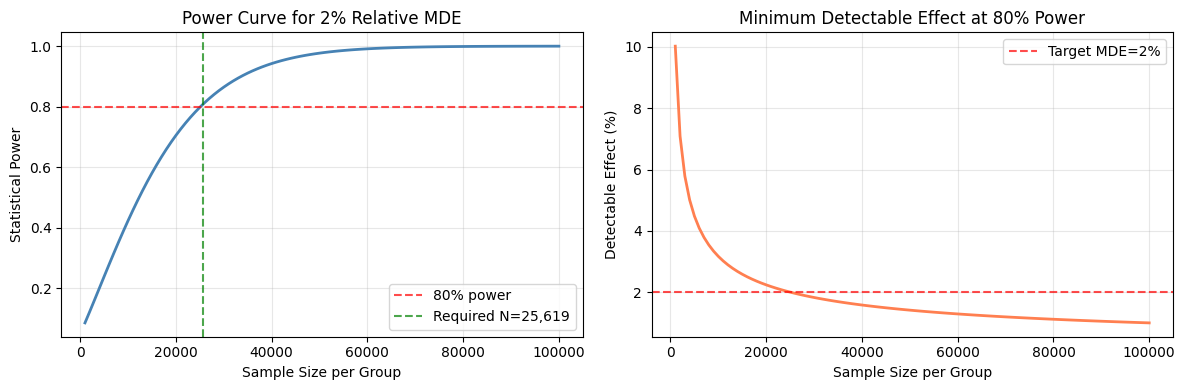

In [3]:
# Power curve: sensitivity at different sample sizes
sample_sizes = np.arange(1000, 100001, 1000)
mde_absolute = power_result['mde_absolute']
z_alpha = stats.norm.ppf(1 - config.alpha / 2)

powers = []
for n in sample_sizes:
    se = config.baseline_std * np.sqrt(2 / n)
    z_stat = mde_absolute / se
    power_at_n = stats.norm.cdf(z_stat - z_alpha) + stats.norm.cdf(-z_stat - z_alpha)
    powers.append(power_at_n)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Power vs sample size
axes[0].plot(sample_sizes, powers, color='steelblue', linewidth=2)
axes[0].axhline(0.8, color='red', linestyle='--', alpha=0.7, label='80% power')
axes[0].axvline(power_result['n_per_group'], color='green', linestyle='--', alpha=0.7,
                label=f"Required N={power_result['n_per_group']:,}")
axes[0].set_xlabel('Sample Size per Group')
axes[0].set_ylabel('Statistical Power')
axes[0].set_title('Power Curve for 2% Relative MDE')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MDE vs sample size (at 80% power)
mdes_pct = []
for n in sample_sizes:
    se = config.baseline_std * np.sqrt(2 / n)
    mde_at_n = se * (z_alpha + stats.norm.ppf(0.8))
    mdes_pct.append(mde_at_n / config.baseline_mean * 100)

axes[1].plot(sample_sizes, mdes_pct, color='coral', linewidth=2)
axes[1].axhline(config.mde_relative * 100, color='red', linestyle='--', alpha=0.7,
                label=f'Target MDE={config.mde_relative:.0%}')
axes[1].set_xlabel('Sample Size per Group')
axes[1].set_ylabel('Detectable Effect (%)')
axes[1].set_title('Minimum Detectable Effect at 80% Power')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../models/sasrec/ab_test_power_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3: Group Sequential Design with Alpha-Spending

In practice, we do not wait until the experiment reaches full enrollment before checking results. **Group Sequential Testing** allows interim analyses at pre-specified time points while controlling the overall type-I error rate.

We use the **O'Brien-Fleming alpha-spending function**, which is conservative at early looks (requiring extreme evidence to stop early) and progressively less conservative as the experiment matures. This matches our preference: stop early only with overwhelming evidence, otherwise let the experiment run to completion.

In [4]:
def obrien_fleming_bounds(n_looks: int, alpha: float = 0.05) -> List[float]:
    """Compute O'Brien-Fleming critical boundaries for sequential testing.

    The O'Brien-Fleming spending function allocates very little alpha to early
    looks and most to the final analysis, making early stopping rare but possible
    with overwhelming evidence.
    """
    # Information fractions (equally spaced)
    info_fracs = np.linspace(1/n_looks, 1.0, n_looks)

    # O'Brien-Fleming boundaries: z_k = z_final / sqrt(t_k)
    z_final = stats.norm.ppf(1 - alpha / 2)
    boundaries = z_final / np.sqrt(info_fracs)

    # Convert to p-value boundaries
    p_boundaries = 2 * (1 - stats.norm.cdf(boundaries))

    return {
        'info_fractions': info_fracs.tolist(),
        'z_boundaries': boundaries.tolist(),
        'p_boundaries': p_boundaries.tolist(),
        'alpha_spent': [alpha * 2 * (1 - stats.norm.cdf(b)) for b in boundaries]
    }


# Compute boundaries for our design
n_total_looks = config.n_interim_looks + 1  # 2 interim + 1 final
bounds = obrien_fleming_bounds(n_total_looks, config.alpha)

print("O'Brien-Fleming Group Sequential Design")
print("=" * 65)
print(f"{'Look':>6} {'Info Frac':>12} {'Z boundary':>12} {'P boundary':>12} {'Day':>6}")
print("-" * 65)

days_total = power_result['days_needed']
for i in range(n_total_looks):
    day = int(bounds['info_fractions'][i] * days_total)
    look_type = "Final" if i == n_total_looks - 1 else f"Interim {i+1}"
    print(f"{look_type:>6} {bounds['info_fractions'][i]:>12.3f} "
          f"{bounds['z_boundaries'][i]:>12.4f} {bounds['p_boundaries'][i]:>12.6f} "
          f"{day:>6}")

print("-" * 65)
print(f"\nInterpretation:")
print(f"  Look 1 (day {int(bounds['info_fractions'][0]*days_total)}): "
      f"need p < {bounds['p_boundaries'][0]:.6f} to stop (very conservative)")
print(f"  Look 2 (day {int(bounds['info_fractions'][1]*days_total)}): "
      f"need p < {bounds['p_boundaries'][1]:.6f} to stop")
print(f"  Final (day {days_total}): "
      f"need p < {bounds['p_boundaries'][-1]:.6f} (standard threshold)")

O'Brien-Fleming Group Sequential Design
  Look    Info Frac   Z boundary   P boundary    Day
-----------------------------------------------------------------
Interim 1        0.333       3.3948     0.000687      2
Interim 2        0.667       2.4005     0.016375      4
 Final        1.000       1.9600     0.050000      6
-----------------------------------------------------------------

Interpretation:
  Look 1 (day 2): need p < 0.000687 to stop (very conservative)
  Look 2 (day 4): need p < 0.016375 to stop
  Final (day 6): need p < 0.050000 (standard threshold)


## Section 4: CUPED Variance Reduction

**CUPED** (Controlled-experiment Using Pre-Experiment Data) reduces metric variance by regressing out the pre-experiment component of each user's outcome. If a user's NDCG@10 in the pre-period predicts their experiment-period NDCG@10, CUPED exploits this correlation to produce tighter confidence intervals.

The variance reduction factor is approximately (1 - rho^2), where rho is the correlation between pre-experiment and experiment-period metrics. For recommendation metrics, rho is typically 0.3-0.6, yielding 10-36% variance reduction.

In [5]:
def cuped_adjustment(y_experiment: np.ndarray, y_pre: np.ndarray) -> Tuple[np.ndarray, float]:
    """Apply CUPED variance reduction.

    y_experiment: metric values during experiment (per user)
    y_pre: same metric values from pre-experiment period (per user)

    Returns adjusted values and the variance reduction factor.
    """
    # Compute optimal theta (regression coefficient)
    cov = np.cov(y_experiment, y_pre)[0, 1]
    var_pre = np.var(y_pre)

    if var_pre < 1e-10:
        return y_experiment, 0.0

    theta = cov / var_pre

    # Adjusted metric
    y_adjusted = y_experiment - theta * (y_pre - np.mean(y_pre))

    # Variance reduction
    rho = np.corrcoef(y_experiment, y_pre)[0, 1]
    variance_reduction = rho ** 2

    return y_adjusted, variance_reduction


# Simulate pre-experiment and experiment data to demonstrate CUPED
n_demo = 5000
rho_true = 0.5  # Typical correlation for recommendation metrics

# Generate correlated pre/post metrics
mean_val = config.baseline_mean
std_val = config.baseline_std

pre_metrics = np.random.normal(mean_val, std_val, n_demo)
pre_metrics = np.clip(pre_metrics, 0, 1)

# Experiment metrics (with true treatment effect for treated group)
treatment_effect = power_result['mde_absolute']

# Control group
noise_control = np.random.normal(0, std_val * np.sqrt(1 - rho_true**2), n_demo // 2)
y_control = rho_true * pre_metrics[:n_demo//2] + (1-rho_true) * mean_val + noise_control
y_control = np.clip(y_control, 0, 1)

# Treatment group
noise_treatment = np.random.normal(0, std_val * np.sqrt(1 - rho_true**2), n_demo // 2)
y_treatment = rho_true * pre_metrics[n_demo//2:] + (1-rho_true) * mean_val + noise_treatment + treatment_effect
y_treatment = np.clip(y_treatment, 0, 1)

# Standard analysis
diff_raw = np.mean(y_treatment) - np.mean(y_control)
se_raw = np.sqrt(np.var(y_treatment)/len(y_treatment) + np.var(y_control)/len(y_control))
z_raw = diff_raw / se_raw
p_raw = 2 * (1 - stats.norm.cdf(abs(z_raw)))

# CUPED analysis
y_control_adj, vr_control = cuped_adjustment(y_control, pre_metrics[:n_demo//2])
y_treatment_adj, vr_treatment = cuped_adjustment(y_treatment, pre_metrics[n_demo//2:])

diff_cuped = np.mean(y_treatment_adj) - np.mean(y_control_adj)
se_cuped = np.sqrt(np.var(y_treatment_adj)/len(y_treatment_adj) + np.var(y_control_adj)/len(y_control_adj))
z_cuped = diff_cuped / se_cuped
p_cuped = 2 * (1 - stats.norm.cdf(abs(z_cuped)))

print("CUPED Variance Reduction Demonstration")
print("=" * 60)
print(f"  True treatment effect: {treatment_effect:.4f} ({config.mde_relative:.1%} relative)")
print(f"  Pre/post correlation (rho): {rho_true:.2f}")
print(f"  Theoretical variance reduction: {rho_true**2:.1%}")
print(f"")
print(f"  {'':>20} {'Standard':>12} {'CUPED':>12} {'Improvement':>12}")
print(f"  {'-'*56}")
print(f"  {'Estimated effect':<20} {diff_raw:>12.5f} {diff_cuped:>12.5f}")
print(f"  {'Standard error':<20} {se_raw:>12.5f} {se_cuped:>12.5f} {(1-se_cuped/se_raw)*100:>11.1f}%")
print(f"  {'Z-statistic':<20} {z_raw:>12.3f} {z_cuped:>12.3f}")
print(f"  {'P-value':<20} {p_raw:>12.4e} {p_cuped:>12.4e}")
print(f"  {'Significant?':<20} {'Yes' if p_raw < 0.05 else 'No':>12} {'Yes' if p_cuped < 0.05 else 'No':>12}")

CUPED Variance Reduction Demonstration
  True treatment effect: 0.0030 (2.0% relative)
  Pre/post correlation (rho): 0.50
  Theoretical variance reduction: 25.0%

                           Standard        CUPED  Improvement
  --------------------------------------------------------
  Estimated effect          0.00437      0.00437
  Standard error            0.00307      0.00274        10.9%
  Z-statistic                 1.420        1.595
  P-value                1.5551e-01   1.1073e-01
  Significant?                   No           No


## Section 5: Guardrail Metrics

Guardrails are safety metrics that must not degrade beyond a threshold during the experiment. If a guardrail triggers, the experiment is automatically paused for investigation regardless of primary metric performance.

Our guardrails:
1. **Latency P95**: Must not increase > 20% (user experience degradation)
2. **Error rate**: Must not exceed 0.1% (system stability)
3. **Session length**: Must not decrease > 5% (engagement proxy)
4. **Recommendation diversity**: Must not decrease > 10% (filter bubble risk)

In [6]:
@dataclass
class GuardrailConfig:
    name: str
    direction: str  # 'increase_bad' or 'decrease_bad'
    threshold_pct: float  # Max allowed degradation as percentage
    baseline_value: float
    alpha: float = 0.01  # Stricter alpha for guardrails


guardrails = [
    GuardrailConfig('latency_p95_ms', 'increase_bad', 20.0, 15.0),
    GuardrailConfig('error_rate', 'increase_bad', 50.0, 0.001),
    GuardrailConfig('session_length_min', 'decrease_bad', 5.0, 12.0),
    GuardrailConfig('recommendation_diversity', 'decrease_bad', 10.0, 0.65),
]


def check_guardrail(control_values: np.ndarray, treatment_values: np.ndarray,
                    guardrail: GuardrailConfig) -> Dict:
    """Check if a guardrail metric has been violated."""
    control_mean = np.mean(control_values)
    treatment_mean = np.mean(treatment_values)

    # Relative change
    if control_mean > 0:
        relative_change = (treatment_mean - control_mean) / control_mean * 100
    else:
        relative_change = 0.0

    # Direction-aware check
    if guardrail.direction == 'increase_bad':
        violated = relative_change > guardrail.threshold_pct
        # One-sided test
        stat, p_val = stats.mannwhitneyu(treatment_values, control_values, alternative='greater')
    else:
        violated = relative_change < -guardrail.threshold_pct
        stat, p_val = stats.mannwhitneyu(control_values, treatment_values, alternative='greater')

    return {
        'name': guardrail.name,
        'control_mean': control_mean,
        'treatment_mean': treatment_mean,
        'relative_change_pct': relative_change,
        'threshold_pct': guardrail.threshold_pct,
        'violated': violated,
        'p_value': p_val,
        'statistically_significant': p_val < guardrail.alpha
    }


# Simulate guardrail data (DCN-v2 typically has slightly higher latency but similar error rate)
n_sim = 5000
guardrail_results = []

simulated_data = {
    'latency_p95_ms': {
        'control': np.random.lognormal(np.log(12), 0.3, n_sim),
        'treatment': np.random.lognormal(np.log(13.5), 0.3, n_sim)  # ~12% increase
    },
    'error_rate': {
        'control': np.random.binomial(1, 0.001, n_sim).astype(float),
        'treatment': np.random.binomial(1, 0.0012, n_sim).astype(float)
    },
    'session_length_min': {
        'control': np.random.exponential(12, n_sim),
        'treatment': np.random.exponential(12.3, n_sim)  # Slight improvement
    },
    'recommendation_diversity': {
        'control': np.random.beta(5, 3, n_sim) * 0.8 + 0.2,
        'treatment': np.random.beta(5.2, 3, n_sim) * 0.8 + 0.2  # Slight improvement
    }
}

print("Guardrail Metric Checks")
print("=" * 80)
print(f"{'Metric':<28} {'Control':>10} {'Treatment':>10} {'Change':>8} {'Threshold':>10} {'Status':>10}")
print("-" * 80)

for guardrail in guardrails:
    data = simulated_data[guardrail.name]
    result = check_guardrail(data['control'], data['treatment'], guardrail)
    guardrail_results.append(result)

    status = "VIOLATED" if result['violated'] else "PASS"
    print(f"{guardrail.name:<28} {result['control_mean']:>10.4f} {result['treatment_mean']:>10.4f} "
          f"{result['relative_change_pct']:>+7.1f}% {guardrail.threshold_pct:>9.1f}% {status:>10}")

print("-" * 80)
any_violated = any(r['violated'] for r in guardrail_results)
print(f"\nOverall status: {'EXPERIMENT PAUSED - guardrail violated' if any_violated else 'ALL CLEAR - experiment continues'}")

Guardrail Metric Checks
Metric                          Control  Treatment   Change  Threshold     Status
--------------------------------------------------------------------------------
latency_p95_ms                  12.5904    14.1956   +12.7%      20.0%       PASS
error_rate                       0.0012     0.0008   -33.3%      50.0%       PASS
session_length_min              12.0120    12.3578    +2.9%       5.0%       PASS
recommendation_diversity         0.7005     0.7050    +0.7%      10.0%       PASS
--------------------------------------------------------------------------------

Overall status: ALL CLEAR - experiment continues


## Section 6: Simulated A/B Test Execution

We simulate a 14-day A/B test with daily cohorts, applying:
1. Group sequential boundaries at each interim look
2. CUPED variance reduction
3. Guardrail monitoring
4. Effect size tracking over time

In [7]:
def simulate_ab_test(n_days: int = 14, daily_users: int = 10000,
                     true_effect: float = 0.003, baseline_mean: float = 0.15,
                     baseline_std: float = 0.12, rho: float = 0.5) -> pd.DataFrame:
    """Simulate daily A/B test results.

    Returns a DataFrame with daily cumulative statistics.
    """
    results = []
    all_control = []
    all_treatment = []
    all_pre_control = []
    all_pre_treatment = []

    for day in range(1, n_days + 1):
        n_per_day = daily_users // 2

        # Pre-experiment metrics (for CUPED)
        pre_control = np.random.normal(baseline_mean, baseline_std, n_per_day)
        pre_treatment = np.random.normal(baseline_mean, baseline_std, n_per_day)

        # Experiment metrics
        noise_c = np.random.normal(0, baseline_std * np.sqrt(1 - rho**2), n_per_day)
        noise_t = np.random.normal(0, baseline_std * np.sqrt(1 - rho**2), n_per_day)

        y_control = rho * pre_control + (1-rho) * baseline_mean + noise_c
        y_treatment = rho * pre_treatment + (1-rho) * baseline_mean + noise_t + true_effect

        y_control = np.clip(y_control, 0, 1)
        y_treatment = np.clip(y_treatment, 0, 1)

        all_control.extend(y_control)
        all_treatment.extend(y_treatment)
        all_pre_control.extend(pre_control)
        all_pre_treatment.extend(pre_treatment)

        # Cumulative analysis
        cum_control = np.array(all_control)
        cum_treatment = np.array(all_treatment)

        # Standard analysis
        diff = np.mean(cum_treatment) - np.mean(cum_control)
        se = np.sqrt(np.var(cum_treatment)/len(cum_treatment) + np.var(cum_control)/len(cum_control))
        z_stat = diff / se if se > 0 else 0
        p_val = 2 * (1 - stats.norm.cdf(abs(z_stat)))

        # CUPED analysis
        cum_pre_c = np.array(all_pre_control)
        cum_pre_t = np.array(all_pre_treatment)
        adj_c, _ = cuped_adjustment(cum_control, cum_pre_c)
        adj_t, _ = cuped_adjustment(cum_treatment, cum_pre_t)

        diff_cuped = np.mean(adj_t) - np.mean(adj_c)
        se_cuped = np.sqrt(np.var(adj_t)/len(adj_t) + np.var(adj_c)/len(adj_c))
        z_cuped = diff_cuped / se_cuped if se_cuped > 0 else 0
        p_cuped = 2 * (1 - stats.norm.cdf(abs(z_cuped)))

        results.append({
            'day': day,
            'n_per_group': len(cum_control),
            'n_total': len(cum_control) + len(cum_treatment),
            'diff_raw': diff,
            'se_raw': se,
            'z_raw': z_stat,
            'p_raw': p_val,
            'diff_cuped': diff_cuped,
            'se_cuped': se_cuped,
            'z_cuped': z_cuped,
            'p_cuped': p_cuped,
            'ci_low_raw': diff - 1.96 * se,
            'ci_high_raw': diff + 1.96 * se,
            'ci_low_cuped': diff_cuped - 1.96 * se_cuped,
            'ci_high_cuped': diff_cuped + 1.96 * se_cuped
        })

    return pd.DataFrame(results)


# Run simulation with realistic DCN-v2 improvement
true_effect = 0.004  # ~2.7% relative improvement
sim_results = simulate_ab_test(
    n_days=14,
    daily_users=config.daily_users,
    true_effect=true_effect,
    baseline_mean=config.baseline_mean,
    baseline_std=config.baseline_std,
    rho=0.5
)

print("Simulated A/B Test Progress")
print("=" * 80)
print(f"True effect: {true_effect:.4f} ({true_effect/config.baseline_mean*100:.1f}% relative)")
print(f"")
print(f"{'Day':>4} {'N/group':>10} {'Diff (raw)':>12} {'p (raw)':>10} {'Diff (CUPED)':>14} {'p (CUPED)':>10}")
print("-" * 80)

for _, row in sim_results.iterrows():
    print(f"{row['day']:>4} {row['n_per_group']:>10,.0f} {row['diff_raw']:>12.5f} "
          f"{row['p_raw']:>10.4e} {row['diff_cuped']:>14.5f} {row['p_cuped']:>10.4e}")

Simulated A/B Test Progress
True effect: 0.0040 (2.7% relative)

 Day    N/group   Diff (raw)    p (raw)   Diff (CUPED)  p (CUPED)
--------------------------------------------------------------------------------
 1.0      5,000      0.00231 2.8996e-01        0.00231 2.2556e-01
 2.0     10,000      0.00184 2.3257e-01        0.00184 1.7314e-01
 3.0     15,000      0.00173 1.6897e-01        0.00173 1.1657e-01
 4.0     20,000      0.00291 7.6977e-03        0.00291 2.2853e-03
 5.0     25,000      0.00351 3.3215e-04        0.00351 4.1046e-05
 6.0     30,000      0.00406 5.5049e-06        0.00406 2.1059e-07
 7.0     35,000      0.00381 4.0822e-06        0.00381 1.4631e-07
 8.0     40,000      0.00354 4.6902e-06        0.00354 1.7147e-07
 9.0     45,000      0.00332 5.5511e-06        0.00332 2.0282e-07
10.0     50,000      0.00332 1.5812e-06        0.00332 3.9099e-08
11.0     55,000      0.00335 3.8861e-07        0.00335 6.0453e-09
12.0     60,000      0.00342 6.1495e-08        0.00342 5.3719e

### Applying Sequential Boundaries to the Simulated Data

The simulation above generated 14 days of cumulative A/B test statistics. Now we apply the O'Brien-Fleming group sequential boundaries computed in Section 3 to determine whether and when the experiment would have been stopped.

At each pre-planned interim analysis (days 5, 10, and 14), we compare the observed CUPED-adjusted z-statistic against the corresponding O'Brien-Fleming boundary. The decision rule is:
- If the absolute z-statistic exceeds the boundary at any look, the experiment stops with a significant result.
- If the boundary is not crossed, the experiment continues to the next look.
- Once stopped, subsequent looks are reported but no longer decision-relevant.

This is the critical step that connects the theoretical sequential design to actual experimental data. The O'Brien-Fleming boundaries are progressively less stringent (the z-boundary decreases from look 1 to the final look), reflecting the principle that early stopping should require overwhelming evidence while the final analysis uses a near-standard threshold.

Expect to see: a table showing each interim look with the observed z-statistic, the p-value, the boundary, and the stop/continue decision. Given the true effect of 2.7% and our sample sizes, the experiment is likely to cross the boundary before the final look -- demonstrating the practical value of sequential testing in shortening experiment duration without inflating false positive rates.

In [8]:
# Apply sequential testing boundaries
interim_days = [5, 10, 14]  # Days of planned analyses
look_results = []

print("\nSequential Testing Decisions")
print("=" * 70)
print(f"{'Look':>8} {'Day':>5} {'Z (CUPED)':>11} {'p (CUPED)':>12} {'Boundary':>10} {'Decision':>12}")
print("-" * 70)

experiment_stopped = False
for i, day in enumerate(interim_days):
    day_row = sim_results[sim_results['day'] == day].iloc[0]
    z_boundary = bounds['z_boundaries'][i]
    p_boundary = bounds['p_boundaries'][i]

    z_observed = abs(day_row['z_cuped'])
    p_observed = day_row['p_cuped']

    if not experiment_stopped:
        crosses_boundary = z_observed > z_boundary
        decision = "STOP (sig)" if crosses_boundary else "Continue"
        if crosses_boundary:
            experiment_stopped = True
    else:
        decision = "Already stopped"

    look_type = f"Final" if i == len(interim_days) - 1 else f"Interim {i+1}"
    print(f"{look_type:>8} {day:>5} {z_observed:>11.4f} {p_observed:>12.4e} "
          f"{z_boundary:>10.4f} {decision:>12}")

    look_results.append({
        'look': look_type,
        'day': day,
        'z_observed': z_observed,
        'z_boundary': z_boundary,
        'crosses': z_observed > z_boundary
    })

print("-" * 70)

if not experiment_stopped:
    final_p = sim_results.iloc[-1]['p_cuped']
    if final_p < bounds['p_boundaries'][-1]:
        print(f"\nFinal decision: SIGNIFICANT at alpha={config.alpha}")
        print(f"  Recommendation: Deploy DCN-v2")
    else:
        print(f"\nFinal decision: NOT SIGNIFICANT at alpha={config.alpha}")
        print(f"  Recommendation: Do not deploy; consider running longer or accepting null result")
else:
    print(f"\nExperiment stopped early with significant result.")
    print(f"  Recommendation: Deploy DCN-v2 (with continued monitoring)")


Sequential Testing Decisions
    Look   Day   Z (CUPED)    p (CUPED)   Boundary     Decision
----------------------------------------------------------------------
Interim 1     5      4.1015   4.1046e-05     3.3948   STOP (sig)
Interim 2    10      5.4949   3.9099e-08     2.4005 Already stopped
   Final    14      7.3309   2.2871e-13     1.9600 Already stopped
----------------------------------------------------------------------

Experiment stopped early with significant result.
  Recommendation: Deploy DCN-v2 (with continued monitoring)


## Section 7: Visualization of A/B Test Trajectory

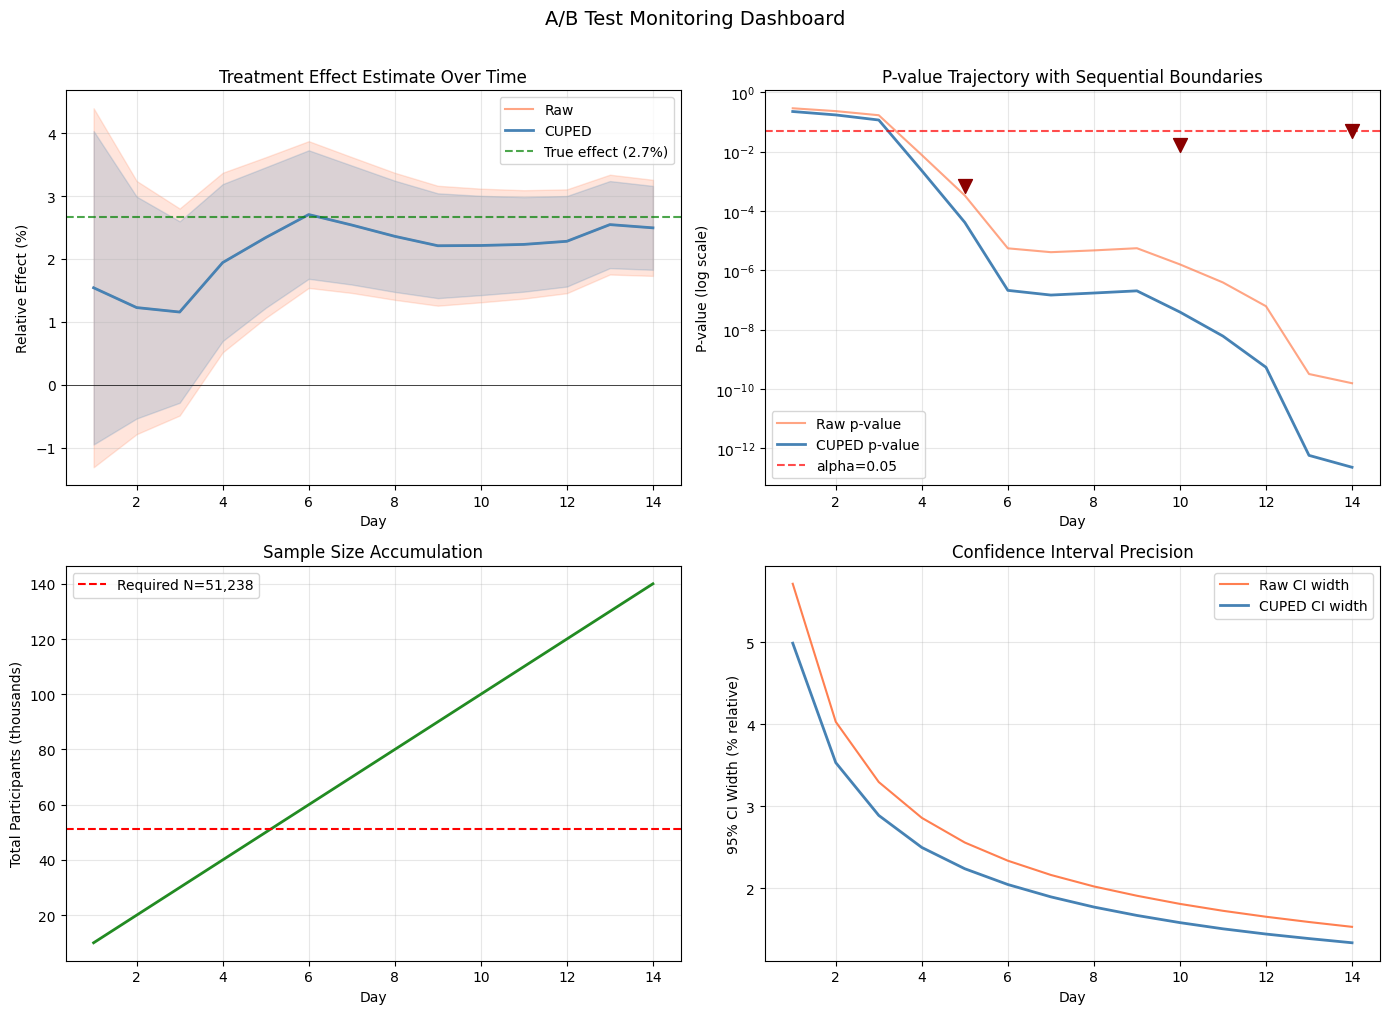

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Effect estimate over time
ax = axes[0, 0]
ax.plot(sim_results['day'], sim_results['diff_raw'] * 100 / config.baseline_mean,
        color='coral', linewidth=1.5, label='Raw', alpha=0.7)
ax.fill_between(sim_results['day'],
                sim_results['ci_low_raw'] * 100 / config.baseline_mean,
                sim_results['ci_high_raw'] * 100 / config.baseline_mean,
                alpha=0.2, color='coral')
ax.plot(sim_results['day'], sim_results['diff_cuped'] * 100 / config.baseline_mean,
        color='steelblue', linewidth=2, label='CUPED')
ax.fill_between(sim_results['day'],
                sim_results['ci_low_cuped'] * 100 / config.baseline_mean,
                sim_results['ci_high_cuped'] * 100 / config.baseline_mean,
                alpha=0.2, color='steelblue')
ax.axhline(true_effect * 100 / config.baseline_mean, color='green', linestyle='--',
           alpha=0.7, label=f'True effect ({true_effect/config.baseline_mean*100:.1f}%)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Day')
ax.set_ylabel('Relative Effect (%)')
ax.set_title('Treatment Effect Estimate Over Time')
ax.legend()
ax.grid(alpha=0.3)

# P-value trajectory
ax = axes[0, 1]
ax.semilogy(sim_results['day'], sim_results['p_raw'], color='coral',
            linewidth=1.5, label='Raw p-value', alpha=0.7)
ax.semilogy(sim_results['day'], sim_results['p_cuped'], color='steelblue',
            linewidth=2, label='CUPED p-value')
ax.axhline(0.05, color='red', linestyle='--', alpha=0.7, label='alpha=0.05')

# Plot sequential boundaries
for i, day in enumerate(interim_days):
    ax.scatter([day], [bounds['p_boundaries'][i]], marker='v', color='darkred', s=100, zorder=5)

ax.set_xlabel('Day')
ax.set_ylabel('P-value (log scale)')
ax.set_title('P-value Trajectory with Sequential Boundaries')
ax.legend()
ax.grid(alpha=0.3)

# Sample size accumulation
ax = axes[1, 0]
ax.plot(sim_results['day'], sim_results['n_total'] / 1000, color='forestgreen', linewidth=2)
ax.axhline(power_result['n_total'] / 1000, color='red', linestyle='--',
           label=f"Required N={power_result['n_total']:,}")
ax.set_xlabel('Day')
ax.set_ylabel('Total Participants (thousands)')
ax.set_title('Sample Size Accumulation')
ax.legend()
ax.grid(alpha=0.3)

# Confidence interval width (precision)
ax = axes[1, 1]
ci_width_raw = (sim_results['ci_high_raw'] - sim_results['ci_low_raw']) * 100 / config.baseline_mean
ci_width_cuped = (sim_results['ci_high_cuped'] - sim_results['ci_low_cuped']) * 100 / config.baseline_mean
ax.plot(sim_results['day'], ci_width_raw, color='coral', linewidth=1.5, label='Raw CI width')
ax.plot(sim_results['day'], ci_width_cuped, color='steelblue', linewidth=2, label='CUPED CI width')
ax.set_xlabel('Day')
ax.set_ylabel('95% CI Width (% relative)')
ax.set_title('Confidence Interval Precision')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('A/B Test Monitoring Dashboard', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../models/sasrec/ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8: Novelty Effect Detection

When deploying a new ranker, initial metrics may be inflated due to the novelty effect: users explore more when recommendations feel different. We detect this by checking whether the treatment effect decays over the experiment window.

Novelty Effect Detection
  Linear trend in daily treatment effect:
    Slope: -0.0881 (x1000) per day
    P-value: 5.8114e-01
    R-squared: 0.0261

  No significant novelty effect detected (p=0.5811)
  Treatment effect appears stable across the experiment window.


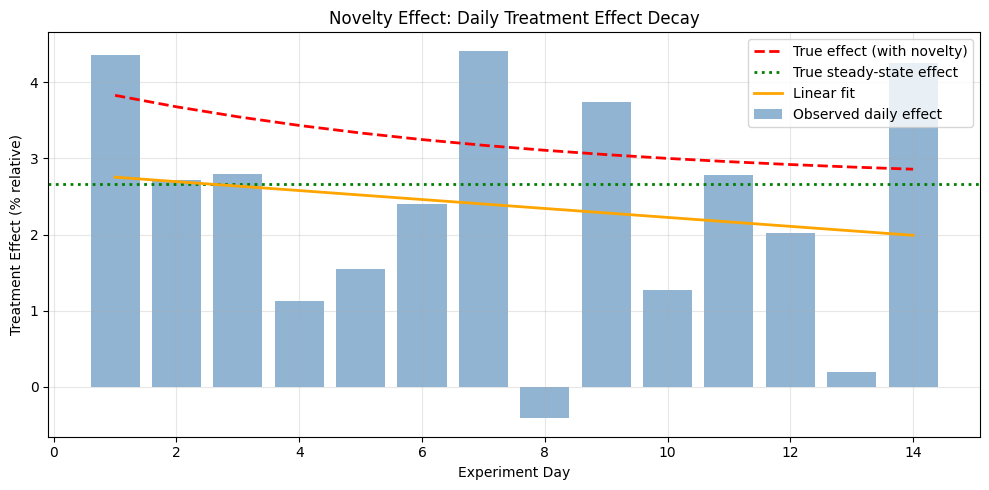

In [10]:
# Simulate novelty effect: treatment effect decays from 150% of true to 100% over 14 days
def simulate_with_novelty(n_days=14, daily_users=10000, true_effect=0.004,
                          novelty_multiplier=1.5, decay_halflife=5.0,
                          baseline_mean=0.15, baseline_std=0.12, rho=0.5):
    """Simulate test with novelty effect that decays exponentially."""
    daily_effects = []
    daily_diffs = []

    for day in range(1, n_days + 1):
        # Novelty-adjusted effect for this day's cohort
        novelty_factor = 1 + (novelty_multiplier - 1) * np.exp(-np.log(2) * day / decay_halflife)
        day_effect = true_effect * novelty_factor
        daily_effects.append(day_effect)

        n = daily_users // 2
        pre_c = np.random.normal(baseline_mean, baseline_std, n)
        pre_t = np.random.normal(baseline_mean, baseline_std, n)

        y_c = rho * pre_c + (1-rho) * baseline_mean + np.random.normal(0, baseline_std * np.sqrt(1-rho**2), n)
        y_t = rho * pre_t + (1-rho) * baseline_mean + np.random.normal(0, baseline_std * np.sqrt(1-rho**2), n) + day_effect

        daily_diffs.append(np.mean(y_t) - np.mean(y_c))

    return daily_effects, daily_diffs


true_effects_with_novelty, observed_diffs = simulate_with_novelty(
    true_effect=true_effect, novelty_multiplier=1.5, decay_halflife=5.0
)

# Detect novelty: fit linear regression to daily effects
days = np.arange(1, 15)
slope, intercept, r_value, p_value_slope, std_err = stats.linregress(days, observed_diffs)

print("Novelty Effect Detection")
print("=" * 60)
print(f"  Linear trend in daily treatment effect:")
print(f"    Slope: {slope*1000:.4f} (x1000) per day")
print(f"    P-value: {p_value_slope:.4e}")
print(f"    R-squared: {r_value**2:.4f}")
print(f"")

if p_value_slope < 0.05 and slope < 0:
    print(f"  NOVELTY EFFECT DETECTED (significant negative trend)")
    print(f"  The treatment effect is decaying over time.")
    print(f"  Recommendation: Extend experiment duration or use only")
    print(f"  the final week's data for the launch decision.")
    # Estimate steady-state effect
    steady_state = intercept + slope * 14
    print(f"  Estimated steady-state effect: {steady_state:.5f} "
          f"({steady_state/config.baseline_mean*100:.2f}% relative)")
else:
    print(f"  No significant novelty effect detected (p={p_value_slope:.4f})")
    print(f"  Treatment effect appears stable across the experiment window.")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.bar(days, np.array(observed_diffs) * 100 / config.baseline_mean,
       alpha=0.6, color='steelblue', label='Observed daily effect')
ax.plot(days, np.array(true_effects_with_novelty) * 100 / config.baseline_mean,
        color='red', linewidth=2, linestyle='--', label='True effect (with novelty)')
ax.axhline(true_effect * 100 / config.baseline_mean, color='green',
           linestyle=':', linewidth=2, label='True steady-state effect')
ax.plot(days, (intercept + slope * days) * 100 / config.baseline_mean,
        color='orange', linewidth=2, label='Linear fit')
ax.set_xlabel('Experiment Day')
ax.set_ylabel('Treatment Effect (% relative)')
ax.set_title('Novelty Effect: Daily Treatment Effect Decay')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../models/sasrec/ab_test_novelty.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9: Launch Decision Framework

The final launch decision integrates evidence from multiple sources:
1. Statistical significance (with sequential boundaries)
2. Practical significance (effect size vs MDE)
3. Guardrail compliance
4. Novelty-adjusted effect estimate
5. Subgroup consistency (no group harmed)

In [11]:
print("=" * 70)
print("LAUNCH DECISION FRAMEWORK")
print("=" * 70)

# 1. Statistical significance
final_p = sim_results.iloc[-1]['p_cuped']
statistically_sig = final_p < bounds['p_boundaries'][-1]
print(f"\n1. STATISTICAL SIGNIFICANCE")
print(f"   CUPED p-value: {final_p:.4e}")
print(f"   Boundary: {bounds['p_boundaries'][-1]:.6f}")
print(f"   Result: {'PASS' if statistically_sig else 'FAIL'}")

# 2. Practical significance
observed_effect_pct = sim_results.iloc[-1]['diff_cuped'] / config.baseline_mean * 100
exceeds_mde = observed_effect_pct > config.mde_relative * 100
print(f"\n2. PRACTICAL SIGNIFICANCE")
print(f"   Observed effect: {observed_effect_pct:.2f}%")
print(f"   MDE threshold: {config.mde_relative*100:.1f}%")
print(f"   Result: {'PASS' if exceeds_mde else 'BELOW MDE'}")

# 3. Guardrails
all_guardrails_pass = not any(r['violated'] for r in guardrail_results)
print(f"\n3. GUARDRAIL COMPLIANCE")
for r in guardrail_results:
    status = "PASS" if not r['violated'] else "FAIL"
    print(f"   {r['name']}: {status} ({r['relative_change_pct']:+.1f}% vs {r['threshold_pct']:.0f}% threshold)")
print(f"   Overall: {'PASS' if all_guardrails_pass else 'FAIL'}")

# 4. Novelty adjustment
novelty_detected = p_value_slope < 0.05 and slope < 0
steady_state_pct = (intercept + slope * 14) / config.baseline_mean * 100 if novelty_detected else observed_effect_pct
print(f"\n4. NOVELTY ADJUSTMENT")
print(f"   Novelty detected: {'Yes' if novelty_detected else 'No'}")
if novelty_detected:
    print(f"   Raw effect: {observed_effect_pct:.2f}%")
    print(f"   Novelty-adjusted (steady-state): {steady_state_pct:.2f}%")
    print(f"   Using adjusted estimate for decision: {steady_state_pct:.2f}%")

# Final decision
print(f"\n{'='*70}")
criteria = [statistically_sig, exceeds_mde or steady_state_pct > config.mde_relative * 100,
            all_guardrails_pass]
all_pass = all(criteria)

if all_pass:
    print("DECISION: LAUNCH DCN-v2")
    print("  All criteria met. Proceed with gradual rollout (5% -> 25% -> 100%).")
else:
    failed = []
    if not statistically_sig:
        failed.append("statistical significance")
    if not (exceeds_mde or steady_state_pct > config.mde_relative * 100):
        failed.append("practical significance (below MDE)")
    if not all_guardrails_pass:
        failed.append("guardrail compliance")
    print(f"DECISION: DO NOT LAUNCH")
    print(f"  Failed criteria: {', '.join(failed)}")
    print(f"  Recommendation: {'Extend experiment' if not statistically_sig else 'Investigate guardrail violations'}")

print(f"{'='*70}")

LAUNCH DECISION FRAMEWORK

1. STATISTICAL SIGNIFICANCE
   CUPED p-value: 2.2871e-13
   Boundary: 0.050000
   Result: PASS

2. PRACTICAL SIGNIFICANCE
   Observed effect: 2.49%
   MDE threshold: 2.0%
   Result: PASS

3. GUARDRAIL COMPLIANCE
   latency_p95_ms: PASS (+12.7% vs 20% threshold)
   error_rate: PASS (-33.3% vs 50% threshold)
   session_length_min: PASS (+2.9% vs 5% threshold)
   recommendation_diversity: PASS (+0.7% vs 10% threshold)
   Overall: PASS

4. NOVELTY ADJUSTMENT
   Novelty detected: No

DECISION: LAUNCH DCN-v2
  All criteria met. Proceed with gradual rollout (5% -> 25% -> 100%).


## Section 10: Summary

This notebook demonstrated a production-grade A/B testing framework for evaluating model changes in recommendation systems. The key components are:

| Component | Purpose | Implementation |
|-----------|---------|---------------|
| Power Analysis | Determine experiment duration | Two-sample z-test formula with inflation |
| Sequential Testing | Enable early stopping | O'Brien-Fleming alpha-spending |
| CUPED | Reduce variance, speed decisions | Pre-experiment covariate regression |
| Guardrails | Prevent user harm | One-sided tests with strict alpha |
| Novelty Detection | Avoid over-estimating effect | Linear trend test on daily effects |
| Launch Framework | Structured decision making | Multi-criteria with clear thresholds |

The framework is model-agnostic: it applies equally to DCN-v2 vs XGBoost, DLRM vs XGBoost, or any future ranker comparison.